In [2]:
import os
import pandas as pd
import shutil

BASE_DIR = r'C:\Users\A S U S\Documents\skin_dataset'
CLASSES = ['Acne', 'Darkspots', 'Redness', 'Wrinkles', 'Normal']

IMG_DIR = os.path.join(BASE_DIR, 'images')
os.makedirs(IMG_DIR, exist_ok=True)

data = []

for i, cls in enumerate(CLASSES):
    folder = os.path.join(BASE_DIR, cls)
    
    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg','.png','.jpeg')):
            
            src = os.path.join(folder, file)
            dst = os.path.join(IMG_DIR, file)
            
            if not os.path.exists(dst):
                shutil.copy(src, dst)
            
            labels = [0]*len(CLASSES)
            labels[i] = 1
            
            data.append([file] + labels)

df = pd.DataFrame(data, columns=['filename'] + CLASSES)
df.to_csv(os.path.join(BASE_DIR, 'labels.csv'), index=False)

print("✅ Dataset ready")

✅ Dataset ready


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

df = pd.read_csv(os.path.join(BASE_DIR, 'labels.csv'))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_dataframe(
    df,
    directory=IMG_DIR,
    x_col='filename',
    y_col=CLASSES,
    target_size=(224,224),
    batch_size=32,
    class_mode='raw',
    subset='training'
)

val_gen = train_datagen.flow_from_dataframe(
    df,
    directory=IMG_DIR,
    x_col='filename',
    y_col=CLASSES,
    target_size=(224,224),
    batch_size=32,
    class_mode='raw',
    subset='validation'
)

Found 6180 validated image filenames.
Found 1544 validated image filenames.


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers[:-30]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(len(CLASSES), activation='sigmoid')(x)

model = models.Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['AUC']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 1,858,181 (7.09 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=4, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(factor=0.3, patience=2)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

C:\Users\A S U S\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 193s 945ms/step - AUC: 0.8808 - loss: 0.3576 - val_AUC: 0.9920 - val_loss: 0.0757 - learning_rate: 3.0000e-04
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 172s 887ms/step - AUC: 0.9901 - loss: 0.0979 - val_AUC: 0.9386 - val_loss: 0.2423 - learning_rate: 3.0000e-04
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 166s 855ms/step - AUC: 0.9963 - loss: 0.0606 - val_AUC: 0.9318 - val_loss: 0.3103 - learning_rate: 3.0000e-04
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 168s 868ms/step - AUC: 0.9983 - loss: 0.0418 - val_AUC: 0.8962 - val_loss: 0.5048 - learning_rate: 9.0000e-05
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 166s 852ms/step - AUC: 0.9989 - loss: 0.0300 - val_AUC: 0.9322 - val_loss: 0.3726 - learning_rate: 9.0000e-05


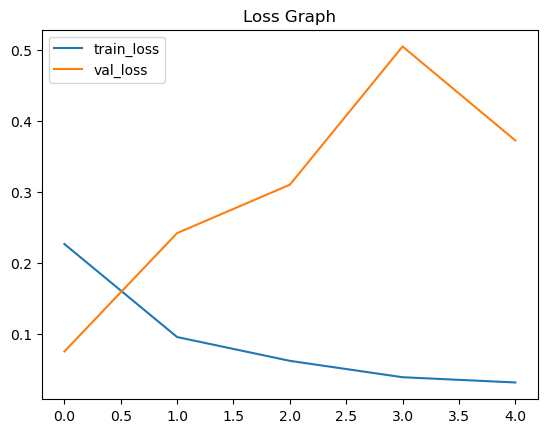

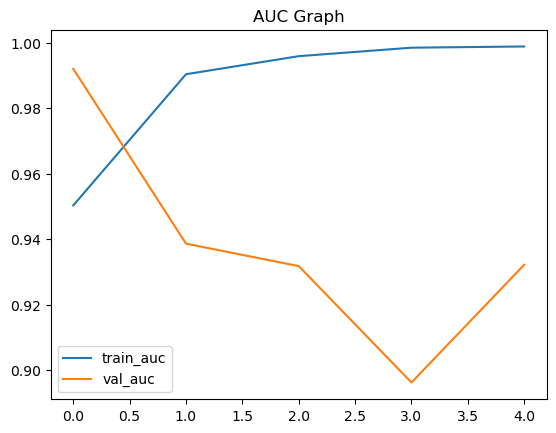

In [7]:
import matplotlib.pyplot as plt

# LOSS
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss Graph')
plt.show()

# AUC
plt.figure()
plt.plot(history.history['AUC'], label='train_auc')
plt.plot(history.history['val_AUC'], label='val_auc')
plt.legend()
plt.title('AUC Graph')
plt.show()

In [8]:
preds = model.predict(val_gen)
y_true = val_gen.labels

# buang Normal column
preds = preds[:, :-1]
y_true = y_true[:, :-1]

preds_binary = (preds > 0.5).astype(int)

exact_acc = np.mean(np.all(preds_binary == y_true, axis=1))
label_acc = np.mean(preds_binary == y_true)

print("Exact Accuracy:", exact_acc)
print("Label Accuracy:", label_acc)

49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 650ms/step
Exact Accuracy: 0.8950777202072538
Label Accuracy: 0.9677784974093264


In [9]:
model.save('model_problem.h5')

import json
with open('label_map_problem.json','w') as f:
    json.dump(CLASSES, f)

print("Model saved")

Model saved


In [10]:
from tensorflow.keras.preprocessing import image

def predict_skin(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0]

    result = {}

    # exclude Normal
    for i, cls in enumerate(CLASSES[:-1]):
        result[cls] = int(pred[i] * 100)

    return result

In [13]:
print(predict_skin(r"C:\Users\A S U S\Documents\skin_dataset\a782b06a3555be4b80b2627d3b417c50.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
{'Acne': 0, 'Darkspots': 3, 'Redness': 1, 'Wrinkles': 0}
